# Sales Forecasting and Demand Prediction: Milestone 1

## Notebook Table of Contents & Structure

| Section Number | Section Title | Key Tasks & Operations Included |
| :--- | :--- | :--- |
| **0** | **Dataset Extraction** | Handling `.zip` extraction programmatically. |
| **1** | **Data Collection & Inspection** | Loading datasets and checking for duplicates. |
| **2** | **Initial EDA** | Descriptive statistics, outlier detection, and skewness analysis. |
| **3** | **Data Cleaning & Preprocessing** | Handling missing values, closed store outliers, and outlier capping. |
| **4** | **Advanced Feature Engineering** | Time-based, custom promo flags, and Lag features. |
| **5** | **Advanced EDA & Visualizations** | Formal dark-mode plots (Trends, Distributions, Correlations, Skewness). |
| **6** | **Encoding & Feature Scaling** | One-Hot Encoding and StandardScaler normalization. |
| **7** | **Dataset Export** | Saving the finalized dataset to `.csv`. |


# Section 0: Dataset Extraction & Setup

## 0.1: Environment Setup & Library Imports
In this step, we import core data science libraries (`pandas`, `numpy`), data visualization tools (`matplotlib`, `seaborn`), and preprocessing modules (`StandardScaler`). We also enforce a globally customized dark mode theme for all generated charts, and define a single reusable styling function so every chart in the notebook stays visually consistent.

## 0.2: Automated Dataset Extraction
This section handles the programmatic extraction of the compressed `.zip` dataset into the dedicated working directory to ensure automated and reproducible execution on any server.

In [9]:
import os
import zipfile
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="dark", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212"})

PALETTE_MAIN = ['#00adb5', '#ff2e63', '#f8b400', '#7bed9f', '#a29bfe', '#ffa502']
GRID_COLOR = '#2a2a2a'

def style_axes(ax, title, xlabel="", ylabel="", rotation=0, legend=False):
    ax.set_title(title, fontsize=15, color='white', pad=16, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12, color='white', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, color='white', labelpad=10)
    ax.tick_params(colors='white', labelsize=10)
    if rotation:
        plt.setp(ax.get_xticklabels(), rotation=rotation, ha='right')
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.6, alpha=0.6)
    ax.grid(axis='x', visible=False)
    for spine in ax.spines.values():
        spine.set_color('#3a3a3a')
    if not legend and ax.get_legend() is not None:
        ax.get_legend().remove()
    return ax

zip_path = "/content/rossmann-store-sales.zip"
extract_to = "/content/rossmann_data/"

if os.path.exists(zip_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted successfully to: {extract_to}")
else:
    print("Zip file not found. Assuming data is already extracted.")

Extracting dataset...
Extracted successfully to: /content/rossmann_data/


# Section 1: Data Collection & Inspection

## 1.1: Data Loading, Merging, and Quality Inspection
Here, we ingest both the `train` and `store` source datasets, perform a crucial data integrity check for row duplicates, synchronize the date format, and execute a left-merge to construct a unified analytics DataFrame.

In [10]:
train_df = pd.read_csv("/content/rossmann_data/train.csv", low_memory=False)
store_df = pd.read_csv("/content/rossmann_data/store.csv")

print(f"Train Dataset Duplicates: {train_df.duplicated().sum()}")
print(f"Store Dataset Duplicates: {store_df.duplicated().sum()}")

train_df['Date'] = pd.to_datetime(train_df['Date'])

df = pd.merge(train_df, store_df, on='Store', how='left')
print(f"Merged DataFrame Shape: {df.shape}")

df.head(10)

Train Dataset Duplicates: 0
Store Dataset Duplicates: 0
Merged DataFrame Shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,5,2015-07-31,8492,833,1,1,0,1,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,5,2015-07-31,8565,687,1,1,0,1,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,5,2015-07-31,7185,681,1,1,0,1,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


# Section 2: Initial Exploratory Data Analysis (EDA)

## 2.1: Initial Statistics & Missing Value Scans
Before altering the data, we compute basic summary statistics for the target variable (`Sales`) and `Customers`. Additionally, we isolate the exact missing value counts across all features to strategize our imputation logic.

In [11]:
print("Summary Statistics for Sales and Customers")
print(df[['Sales', 'Customers']].describe())

print("\nMissing Values Count")
print(df.isnull().sum()[df.isnull().sum() > 0])

Summary Statistics for Sales and Customers
              Sales     Customers
count  1.017209e+06  1.017209e+06
mean   5.773819e+03  6.331459e+02
std    3.849926e+03  4.644117e+02
min    0.000000e+00  0.000000e+00
25%    3.727000e+03  4.050000e+02
50%    5.744000e+03  6.090000e+02
75%    7.856000e+03  8.370000e+02
max    4.155100e+04  7.388000e+03

Missing Values Count
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


## 2.2: Outlier Detection

Before deciding on any cleaning strategy, we visually inspect the distribution of the key numerical columns using boxplots, then quantify outliers formally using the **IQR (Interquartile Range) method**:

`Lower Bound = Q1 - 1.5 * IQR`, `Upper Bound = Q3 + 1.5 * IQR`

Note: at this stage the dataset still includes closed-store days (`Sales = 0`), which will show up as a large block of low-end outliers — this is expected and is handled separately in Section 3.

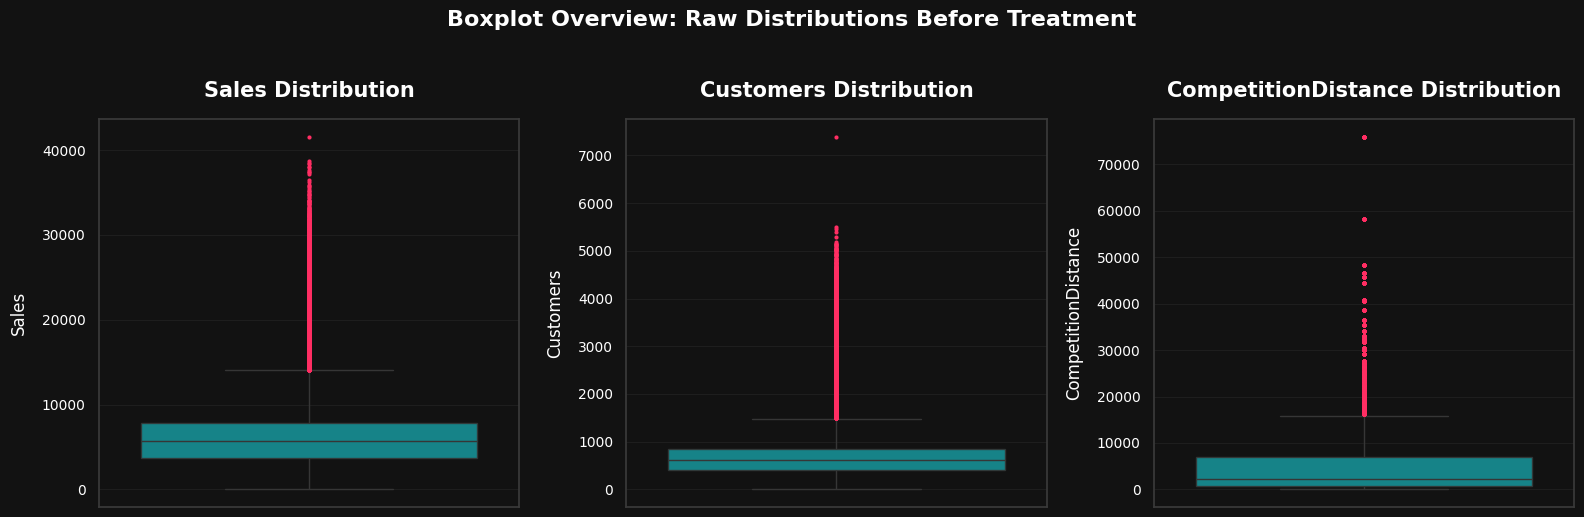

IQR-Based Outlier Summary (raw data)
 - Sales                  Lower=   -2466.5  Upper=   14049.5  Outliers=  26694 (2.62%)
 - Customers              Lower=    -243.0  Upper=    1485.0  Outliers=  38095 (3.75%)
 - CompetitionDistance    Lower=   -8560.0  Upper=   16160.0  Outliers=  99160 (9.75%)


In [12]:
outlier_cols = ['Sales', 'Customers', 'CompetitionDistance']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#121212')

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color=PALETTE_MAIN[0], fliersize=2,
                boxprops=dict(alpha=0.85), flierprops=dict(markerfacecolor=PALETTE_MAIN[1], markeredgecolor='none', markersize=3))
    style_axes(ax, f'{col} Distribution', ylabel=col)

plt.suptitle('Boxplot Overview: Raw Distributions Before Treatment', fontsize=16, color='white', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

print("IQR-Based Outlier Summary (raw data)")
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct = 100 * n_outliers / len(df)
    print(f" - {col:<22} Lower={lower:>10.1f}  Upper={upper:>10.1f}  Outliers={n_outliers:>7} ({pct:.2f}%)")

## 2.3: Skewness Analysis

We measure the skewness of the core numerical features to understand how far they deviate from a symmetric (normal) distribution. As a rule of thumb: `|skew| < 0.5` is roughly symmetric, `0.5-1` is moderately skewed, and `> 1` is highly skewed — which matters because many models (and metrics like RMSE) are sensitive to long-tailed distributions.

The columns checked here are `Sales` (the target variable), `Customers` (the feature most strongly correlated with `Sales`), and `CompetitionDistance` (a continuous feature that also gets scaled later) — these are the continuous numerical columns that actually feed into the model as features or target, as opposed to categorical or binary columns where skewness has no meaningful interpretation.

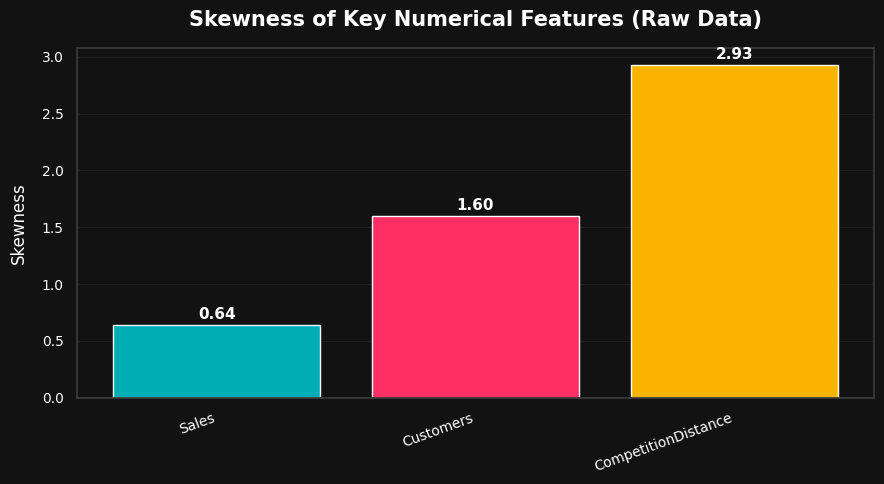

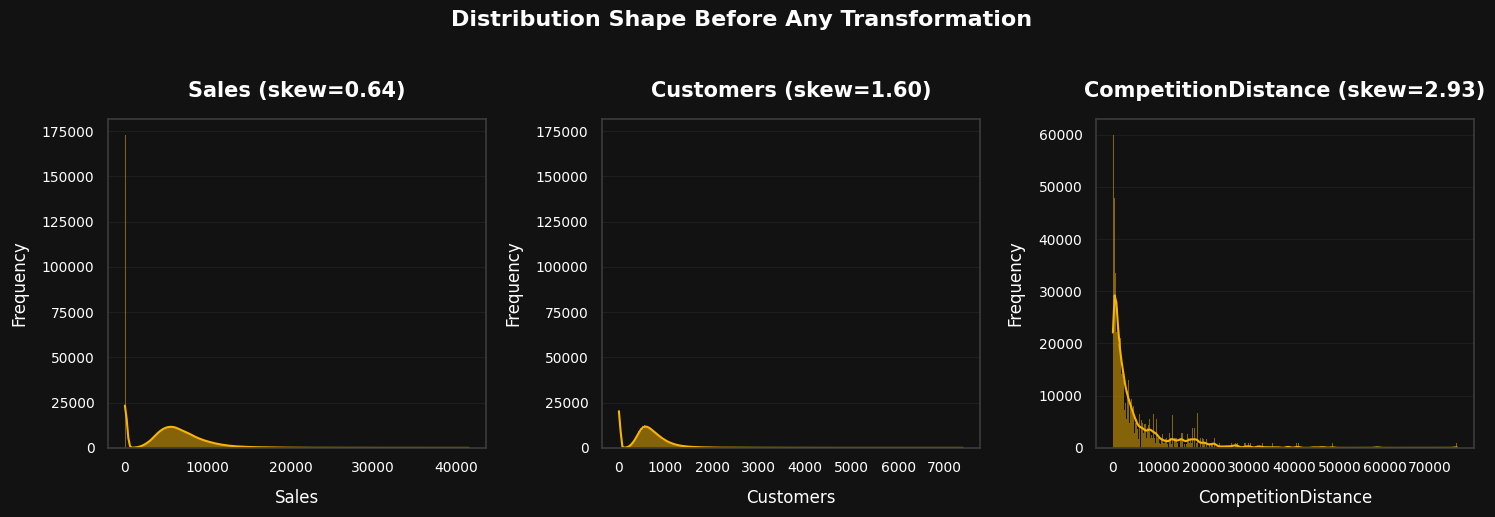

Skewness values: {'Sales': np.float64(0.641), 'Customers': np.float64(1.599), 'CompetitionDistance': np.float64(2.929)}


In [13]:
skew_cols = ['Sales', 'Customers', 'CompetitionDistance', 'Sales_Lag_7', 'Sales_Lag_30', 'CompetitionOpen']
skew_values = {col: skew(df[col].dropna()) for col in skew_cols if col in df.columns}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(skew_values.keys(), skew_values.values(), color=PALETTE_MAIN[:len(skew_values)])
for bar, val in zip(bars, skew_values.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}',
            ha='center', color='white', fontsize=11, fontweight='bold')
ax.axhline(0, color='#555555', linewidth=1)
style_axes(ax, 'Skewness of Key Numerical Features (Raw Data)', ylabel='Skewness', rotation=20)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(skew_values), figsize=(5 * len(skew_values), 5))
fig.patch.set_facecolor('#121212')
for ax, col in zip(axes, skew_values.keys()):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=PALETTE_MAIN[2], edgecolor='none')
    style_axes(ax, f'{col} (skew={skew_values[col]:.2f})', xlabel=col, ylabel='Frequency')

plt.suptitle('Distribution Shape Before Any Transformation', fontsize=16, color='white', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness values:", {k: round(v, 3) for k, v in skew_values.items()})

# Section 3: Data Cleaning & Preprocessing

## 3.1: Missing Value Imputation and Outlier Filtering
In this stage, missing values are imputed programmatically using business logic. Before imputing the competition-related date fields, we save a `*_Missing` flag — this preserves the information of "no competition data available" so it isn't accidentally treated as "competition has existed since year 0" later in Section 4. Furthermore, operational outliers — such as closed store days where sales are zero — are filtered out to eliminate target variable distortion.

In [14]:
df['CompetitionData_Missing'] = df['CompetitionOpenSinceYear'].isna()
df['Promo2Data_Missing'] = df['Promo2SinceYear'].isna()

df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0).astype(int)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0).astype(int)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0).astype(int)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0).astype(int)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

df = df[df['Open'] != 0]
print(f"Missing values handled. Filtered out closed store noise (Outliers). Current Shape: {df.shape}")

Missing values handled. Filtered out closed store noise (Outliers). Current Shape: (844392, 20)


In [15]:
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionData_Missing,Promo2Data_Missing
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9,2008,0,0,0,None,False,True
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",False,False
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",False,False
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9,2009,0,0,0,None,False,True
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4,2015,0,0,0,None,False,True
5,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,12,2013,0,0,0,None,False,True
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,4,2013,0,0,0,None,False,True
7,8,5,2015-07-31,8492,833,1,1,0,1,a,a,7520.0,10,2014,0,0,0,None,False,True
8,9,5,2015-07-31,8565,687,1,1,0,1,a,c,2030.0,8,2000,0,0,0,None,False,True
9,10,5,2015-07-31,7185,681,1,1,0,1,a,a,3160.0,9,2009,0,0,0,None,False,True


## 3.2: Outlier Treatment (IQR Capping)

Now that closed-store noise has been removed, we treat the remaining statistical outliers in `Customers` and `CompetitionDistance` using **IQR-based capping (winsorization)**: values beyond the IQR bounds are clipped to the bound itself, rather than deleted — this keeps every row in the dataset (important for the `Sales_Lag_7` time-series feature built in Section 4) while reducing the influence of extreme values.

`Sales` is intentionally **left untouched** here: it is the target variable, and its high values (holiday spikes, promo days) are genuine business events rather than data errors — capping the target would erase real signal the model needs to learn.

 - Customers              capped 40853 values to range [0.0, 1454.0]
 - CompetitionDistance    capped 83041 values to range [0.0, 16135.0]


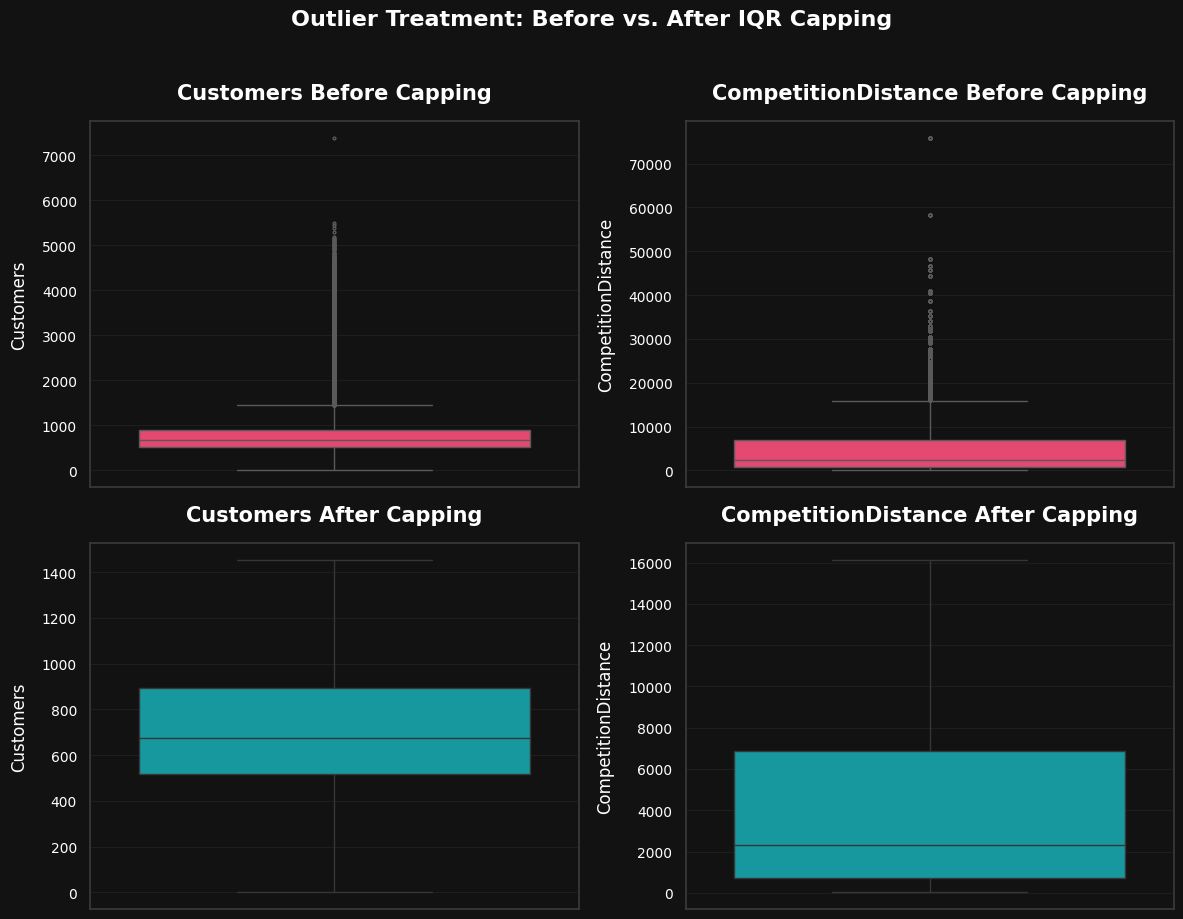

In [16]:
cap_cols = ['Customers', 'CompetitionDistance']
before = df[cap_cols].copy()

for col in cap_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    lower = max(lower, 0)
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f" - {col:<22} capped {n_capped} values to range [{lower:.1f}, {upper:.1f}]")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.patch.set_facecolor('#121212')
for i, col in enumerate(cap_cols):
    sns.boxplot(y=before[col], ax=axes[0, i], color=PALETTE_MAIN[1], fliersize=2)
    style_axes(axes[0, i], f'{col} Before Capping', ylabel=col)
    sns.boxplot(y=df[col], ax=axes[1, i], color=PALETTE_MAIN[0], fliersize=2)
    style_axes(axes[1, i], f'{col} After Capping', ylabel=col)

plt.suptitle('Outlier Treatment: Before vs. After IQR Capping', fontsize=16, color='white', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Section 4: Advanced Feature Engineering

## 4.1: Feature Generation & Time-Series Lags
To capture complex cyclical patterns, we decompose the date column into granular time-based features. We then engineer custom business properties, correcting two logical issues found in the previous version of this notebook:

- **`CompetitionOpen`** now uses the `CompetitionData_Missing` flag from Section 3.1, so stores with no competition data are correctly assigned `0` months of competition exposure, instead of an inflated value implying competition open since "year 0".
- **`Promo2Active`** now correctly converts the numeric month into its 3-letter abbreviation (e.g. `7 -> 'Jul'`) before checking membership in `PromoInterval` (which stores month names, not numbers) — the previous version compared a number to a name and always evaluated to `0`.
- **`Sales_Lag_7`** is now computed via a calendar-date self-join (matching each row to the same Store exactly 7 calendar days earlier), instead of a plain `shift(7)` on row order — the previous version silently mixed up "7 rows ago" with "7 calendar days ago" whenever a store had closed days removed in between.
- **`Sales_Lag_30`** is added alongside `Sales_Lag_7`, using the same calendar-date join logic, to capture a monthly lag signal in addition to the weekly one.

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Quarter'] = df['Date'].dt.quarter

raw_competition_open = 12 * (df['Year'] - df['CompetitionOpenSinceYear']) + (df['Month'] - df['CompetitionOpenSinceMonth'])
df['CompetitionOpen'] = np.where(df['CompetitionData_Missing'], 0, raw_competition_open)
df['CompetitionOpen'] = df['CompetitionOpen'].clip(lower=0)

month_abbr = df['Month'].map(lambda m: calendar.month_abbr[m])
promo_month_match = pd.Series(
    [abbr in interval.split(',') for abbr, interval in zip(month_abbr, df['PromoInterval'])],
    index=df.index
)
df['Promo2Active'] = ((df['Promo2'] == 1) & promo_month_match).astype(int)

df = df.sort_values(by=['Store', 'Date']).reset_index(drop=True)

def add_calendar_lag(frame, days):
    lag_source = frame[['Store', 'Date', 'Sales']].copy()
    lag_source['Date'] = lag_source['Date'] + pd.Timedelta(days=days)
    lag_source = lag_source.rename(columns={'Sales': f'Sales_Lag_{days}'})
    frame = frame.merge(lag_source, on=['Store', 'Date'], how='left')
    frame[f'Sales_Lag_{days}'] = frame[f'Sales_Lag_{days}'].fillna(0)
    return frame

df = add_calendar_lag(df, 7)
df = add_calendar_lag(df, 30)

print("Engineered time-based features, corrected promo flags, and corrected Sales Lag features (7-day and 30-day).")

df[['Date', 'Store', 'Sales', 'Sales_Lag_7', 'Sales_Lag_30', 'Year', 'Month', 'Promo2Active']].head(15)

Engineered time-based features, corrected promo flags, and corrected Sales Lag features (7-day and 30-day).


,Date,Store,Sales,Sales_Lag_7,Sales_Lag_30,Year,Month,Promo2Active
0,2013-01-02,1,5530,0.0,0.0,2013,1,0
1,2013-01-03,1,4327,0.0,0.0,2013,1,0
2,2013-01-04,1,4486,0.0,0.0,2013,1,0
3,2013-01-05,1,4997,0.0,0.0,2013,1,0
4,2013-01-07,1,7176,0.0,0.0,2013,1,0
5,2013-01-08,1,5580,0.0,0.0,2013,1,0
6,2013-01-09,1,5471,5530.0,0.0,2013,1,0
7,2013-01-10,1,4892,4327.0,0.0,2013,1,0
8,2013-01-11,1,4881,4486.0,0.0,2013,1,0
9,2013-01-12,1,4952,4997.0,0.0,2013,1,0


# Section 5: Advanced EDA & Visualizations

## 5.1: Formal Dark-Mode Visual Analysis
With the dataset cleaned, corrected, and fully feature-engineered — but still in its readable categorical form (before One-Hot Encoding) — we run a broader set of formal, consistently-styled visualizations: temporal sales trends, promo effects, categorical breakdowns, skewness re-check, and a correlation matrix. Every chart below uses the same `style_axes()` helper defined in Section 0, so fonts, colors, and layout stay consistent throughout.

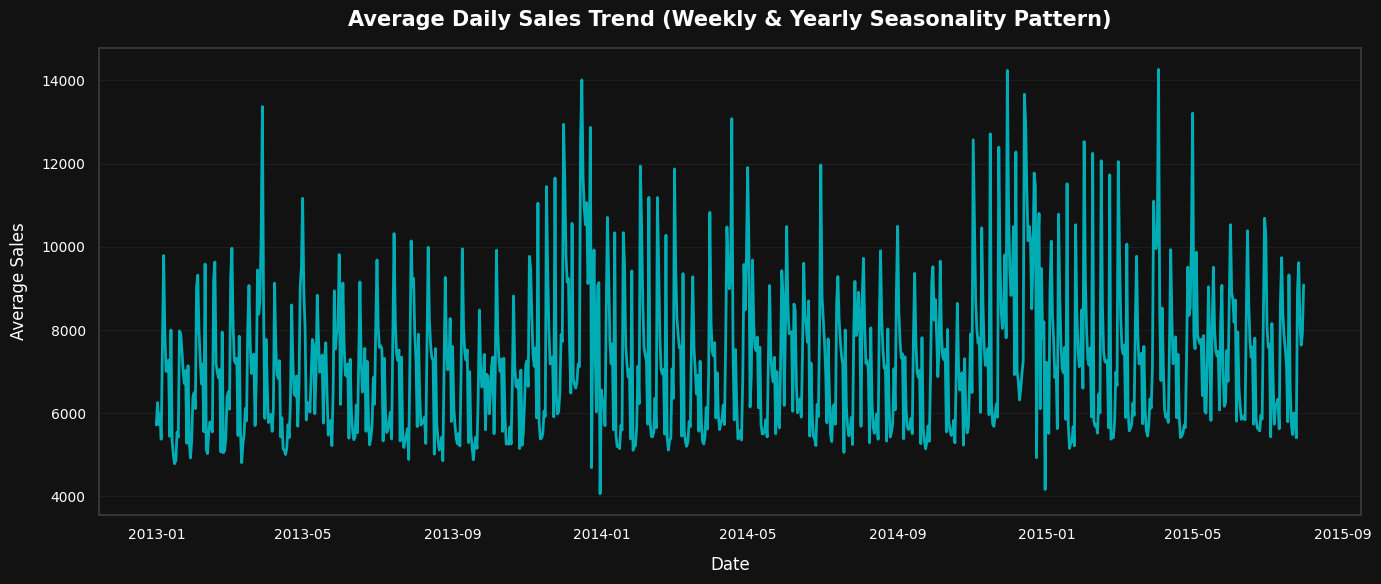

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
df_trend = df.groupby('Date')['Sales'].mean().reset_index()
sns.lineplot(data=df_trend, x='Date', y='Sales', color=PALETTE_MAIN[0], linewidth=2, ax=ax)
style_axes(ax, 'Average Daily Sales Trend (Weekly & Yearly Seasonality Pattern)', 'Date', 'Average Sales')
plt.tight_layout()
plt.show()

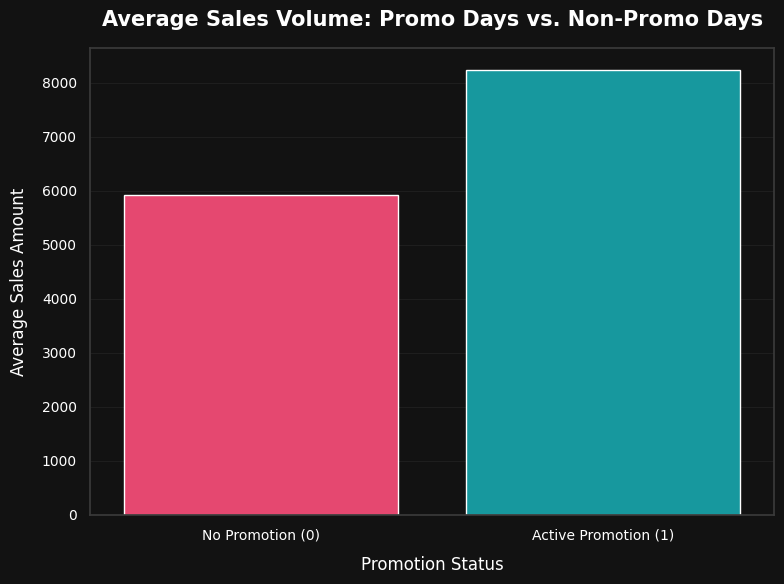

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df, x='Promo', y='Sales', hue='Promo', palette=[PALETTE_MAIN[1], PALETTE_MAIN[0]],
            legend=False, errorbar=None, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Promotion (0)', 'Active Promotion (1)'])
style_axes(ax, 'Average Sales Volume: Promo Days vs. Non-Promo Days', 'Promotion Status', 'Average Sales Amount')
plt.tight_layout()
plt.show()

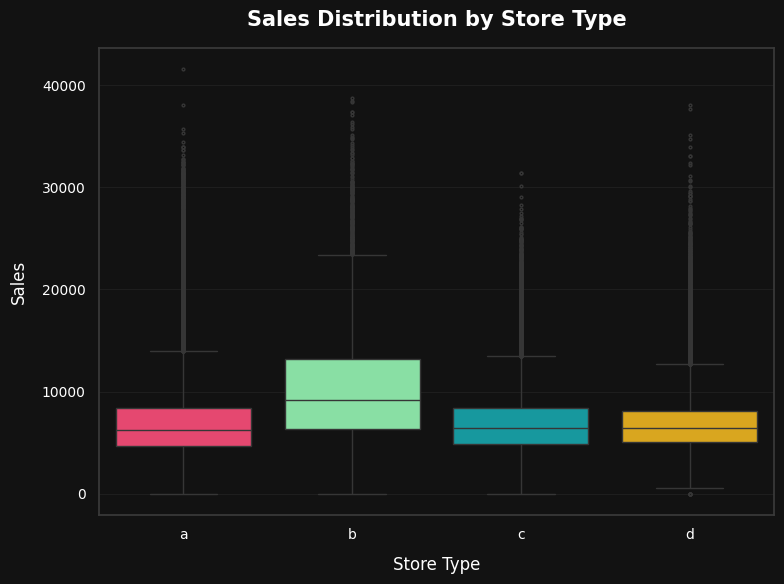

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
storetype_order = sorted(df['StoreType'].unique())
sns.boxplot(data=df, x='StoreType', y='Sales', hue='StoreType', palette=PALETTE_MAIN[:len(storetype_order)], legend=False,
            order=storetype_order, fliersize=2, ax=ax)
style_axes(ax, 'Sales Distribution by Store Type', 'Store Type', 'Sales')
plt.tight_layout()
plt.show()

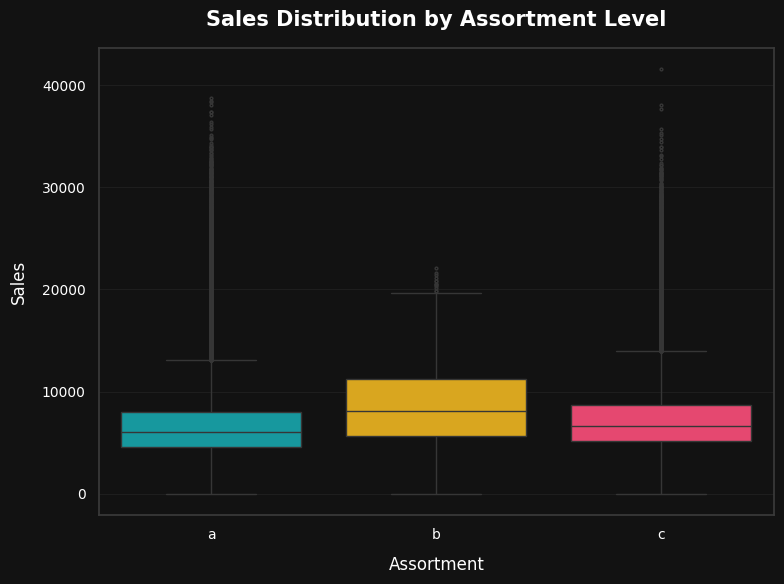

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
assortment_order = sorted(df['Assortment'].unique())
sns.boxplot(data=df, x='Assortment', y='Sales', hue='Assortment', palette=PALETTE_MAIN[:len(assortment_order)], legend=False,
            order=assortment_order, fliersize=2, ax=ax)
style_axes(ax, 'Sales Distribution by Assortment Level', 'Assortment', 'Sales')
plt.tight_layout()
plt.show()

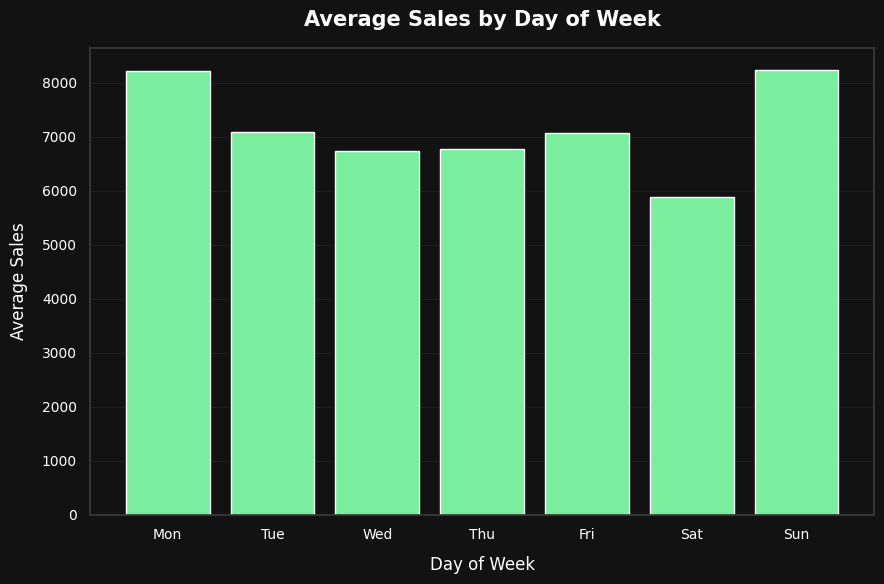

In [22]:
dow_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_avg = df.groupby('DayOfWeek')['Sales'].mean().reindex(range(1, 8))

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar([dow_labels[d] for d in dow_avg.index], dow_avg.values, color=PALETTE_MAIN[3])
style_axes(ax, 'Average Sales by Day of Week', 'Day of Week', 'Average Sales')
plt.tight_layout()
plt.show()

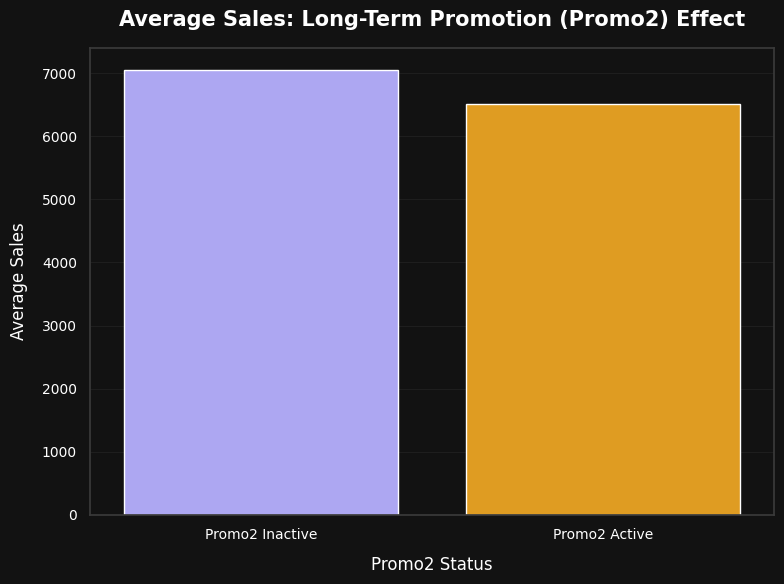

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df, x='Promo2Active', y='Sales', hue='Promo2Active', palette=[PALETTE_MAIN[4], PALETTE_MAIN[5]],
            legend=False, errorbar=None, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Promo2 Inactive', 'Promo2 Active'])
style_axes(ax, 'Average Sales: Long-Term Promotion (Promo2) Effect', 'Promo2 Status', 'Average Sales')
plt.tight_layout()
plt.show()

## 5.2: Skewness Re-Check (Post Outlier Treatment)

We re-measure skewness after the Section 3.2 capping step to confirm the treatment reduced the long tail in `Customers` and `CompetitionDistance`. We also compare `Sales` against its `log1p`-transformed version, and re-check `Sales_Lag_7` and `CompetitionOpen` from Section 2.3. `Sales_Log` is kept only for visual comparison here and is not used to overwrite the original target.

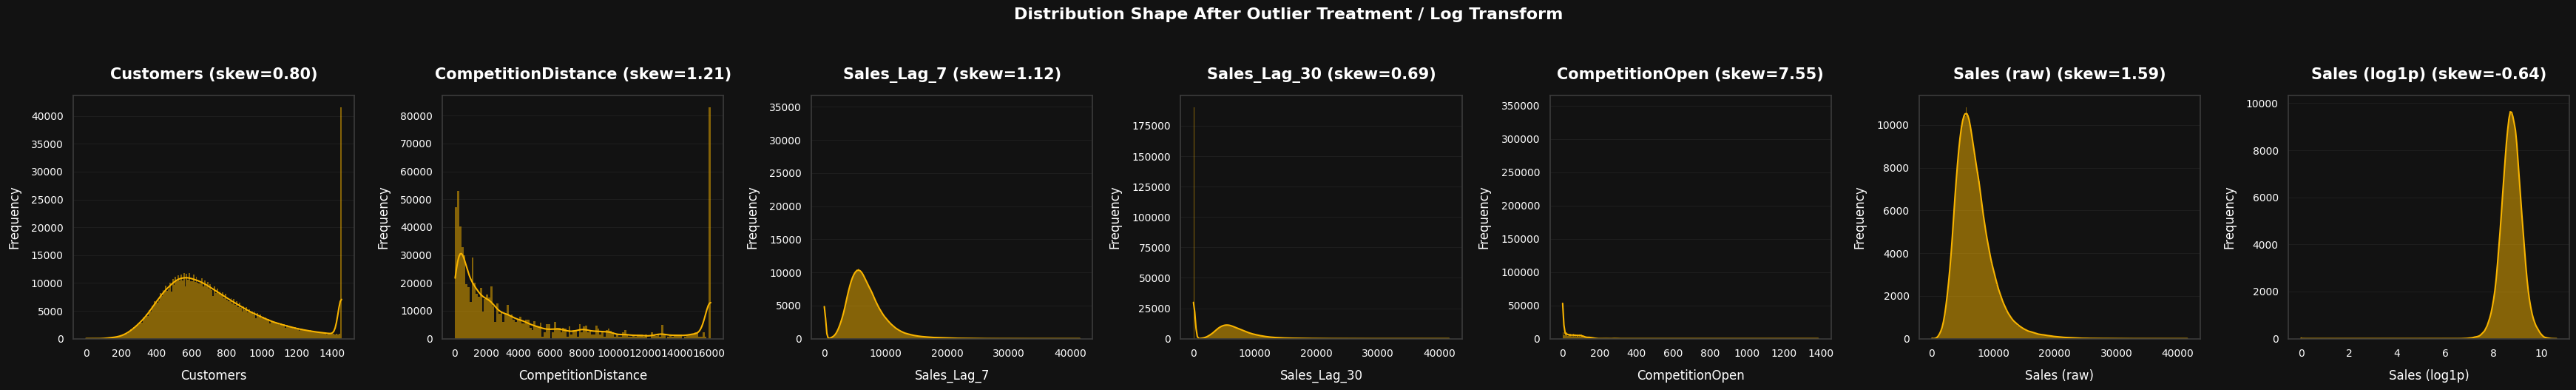

Skewness after treatment:
 - Customers            skew = 0.803
 - CompetitionDistance  skew = 1.212
 - Sales_Lag_7          skew = 1.120
 - Sales_Lag_30         skew = 0.687
 - CompetitionOpen      skew = 7.548
 - Sales (raw)          skew = 1.594
 - Sales (log1p)        skew = -0.638


In [24]:
df['Sales_Log'] = np.log1p(df['Sales'])

compare_cols = {
    'Customers': 'Customers',
    'CompetitionDistance': 'CompetitionDistance',
    'Sales_Lag_7': 'Sales_Lag_7',
    'Sales_Lag_30': 'Sales_Lag_30',
    'CompetitionOpen': 'CompetitionOpen',
    'Sales (raw)': 'Sales',
    'Sales (log1p)': 'Sales_Log',
}

fig, axes = plt.subplots(1, len(compare_cols), figsize=(5 * len(compare_cols), 5))
fig.patch.set_facecolor('#121212')
for ax, (label, col) in zip(axes, compare_cols.items()):
    s = skew(df[col].dropna())
    sns.histplot(df[col], kde=True, ax=ax, color=PALETTE_MAIN[2], edgecolor='none')
    style_axes(ax, f'{label} (skew={s:.2f})', xlabel=label, ylabel='Frequency', rotation=0)

plt.suptitle('Distribution Shape After Outlier Treatment / Log Transform', fontsize=16, color='white', y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness after treatment:")
for label, col in compare_cols.items():
    print(f" - {label:<20} skew = {skew(df[col].dropna()):.3f}")

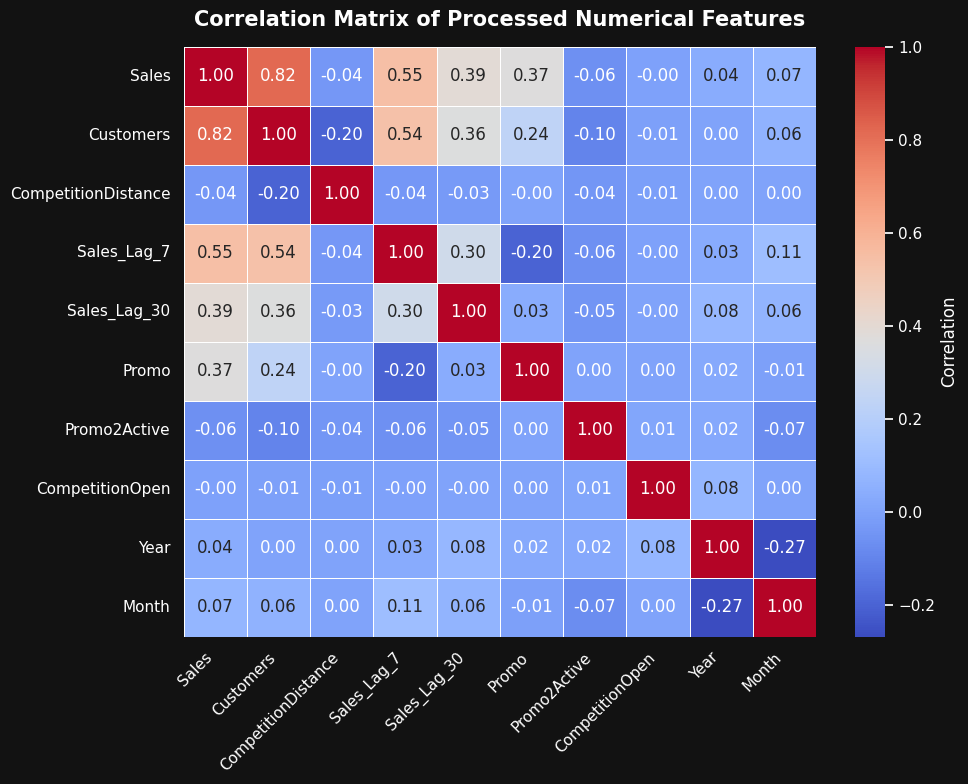

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
core_cols = ['Sales', 'Customers', 'CompetitionDistance', 'Sales_Lag_7', 'Sales_Lag_30', 'Promo', 'Promo2Active', 'CompetitionOpen', 'Year', 'Month']
sns.heatmap(df[core_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation'})

ax.set_xticklabels(ax.get_xticklabels(), color='white', fontsize=11, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), color='white', fontsize=11)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')
cbar.set_label('Correlation', color='white')

ax.set_title('Correlation Matrix of Processed Numerical Features', fontsize=15, color='white', pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Section 6: Categorical Encoding & Feature Scaling

## 6.1: Categorical Encoding & Normalization
To prepare features for downstream machine learning algorithms, categorical text labels are encoded via One-Hot Encoding. Concurrently, continuous variables like `CompetitionDistance`, `Sales_Lag_7`, and `Sales_Lag_30` are normalized using `StandardScaler`.

> **Important for the next milestone:** the `scaler` object below is fit only on this training data. When `test.csv` is processed later, it must go through `scaler.transform()` (never `scaler.fit_transform()`) using this exact same fitted object, so both sets share identical scaling statistics.

In [26]:
df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 0: 0, 'a': 1, 'b': 1, 'c': 1}).astype(int)

df = pd.get_dummies(df, columns=['StoreType', 'Assortment', 'DayOfWeek'], drop_first=True)

scaler = StandardScaler()
scaled_features = ['CompetitionDistance', 'Sales_Lag_7', 'Sales_Lag_30']
df[scaled_features] = scaler.fit_transform(df[scaled_features])

df.head()

,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StoreType_c,StoreType_d,Assortment_b,Assortment_c,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,DayOfWeek_7
0,1,2013-01-02,5530,668,1,0,0,1,-0.649869,9,...,True,False,False,False,False,True,False,False,False,False
1,1,2013-01-03,4327,578,1,0,0,1,-0.649869,9,...,True,False,False,False,False,False,True,False,False,False
2,1,2013-01-04,4486,619,1,0,0,1,-0.649869,9,...,True,False,False,False,False,False,False,True,False,False
3,1,2013-01-05,4997,635,1,0,0,1,-0.649869,9,...,True,False,False,False,False,False,False,False,True,False
4,1,2013-01-07,7176,785,1,1,0,1,-0.649869,9,...,True,False,False,False,False,False,False,False,False,False


# Section 7: Preprocessed Dataset Export

## 7.1: Preprocessed Dataset Export
The final operation of the Milestone 1 pipeline exports the fully optimized, cleaned, and normalized DataFrame as a processed `.csv` file.

In [27]:
output_path = "/content/cleaned_rossmann_data.csv"
df.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")
print(f"Final Shape: {df.shape}")

Saved cleaned dataset to: /content/cleaned_rossmann_data.csv
Final Shape: (844392, 39)
